# CUSTOMER CHURN PREDICTION FOR SYRIA TEL COMPANY

## BUSINESS UNDERSTANDING

Customer churn is a significant issue in Syria Tel Company as it result in loss of revenue, customer disatisfaction and increase in cost of acquiring new customers to replace them.
The goal of this project is to build a model that can predict whether a customer will churn in the near future. 
This can be formulated using binary classification where:

1 = customer will churn

0 = customer will remain

using selected features.

The goal is to identify high-risk customers early,enabling SyriaTel to take targeted retention actions before they churn.

## Business Objective
1.To retain Valuable customers

2.To increase customer satisfaction

3.To reduce revenue loss

4.To optimize marketing and retention efforts

## Why Machine learning
Machine Learning is appropriate for this problem because customer churn is influenced by multiple interacting factors that are hard to model using traditional statistical methods.Machine laerning enable discovery of hidden patterns, support individualization predictions and can adapt overtime as customer behaviors evolve.

Additionally features like customer service calls interact non-linearly with churn , a tree-based model can capture threshold effects (e.g. calls > 4) that a linear model cannot

## DATA UNDERSTANDING (EDA)

In [77]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score,roc_curve, f1_score 
from sklearn.tree import plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold



In [78]:
## Load Data set
df= pd. read_csv('Syria Tel Customer churn.csv')
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [79]:
# Data Information
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(3333, 21)
Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333

In [80]:
# checking duplicates
df.duplicated().sum()


0

In [81]:
#checking for missing values
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [82]:
## checking imbalance

df['churn'].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

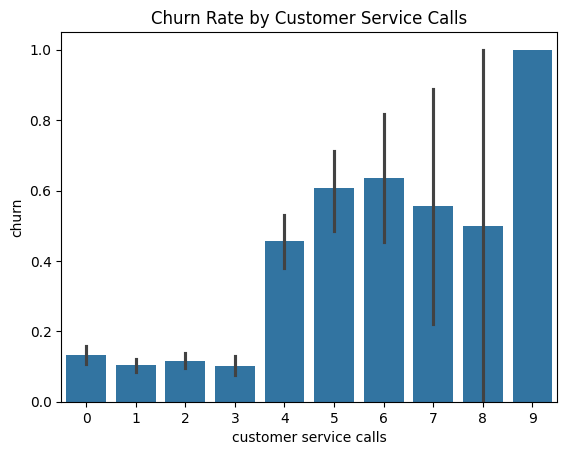

In [83]:
#Customer Service calls Vs Churn
sns.barplot(x='customer service calls', y='churn', data=df)
plt.title("Churn Rate by Customer Service Calls")
plt.show()


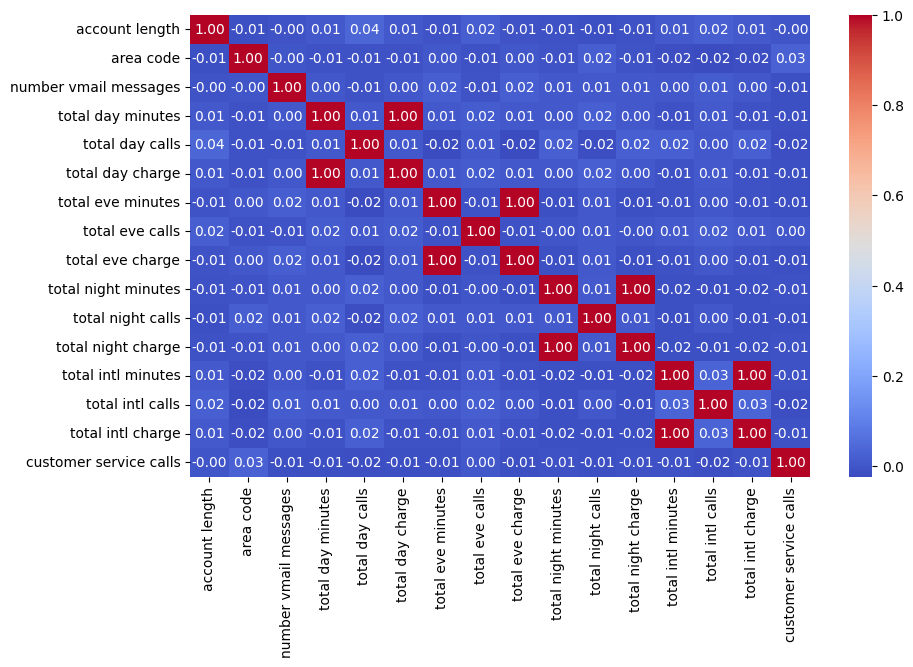

In [84]:
#finding correlation of the features
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()


In [85]:
#check correlation with churn
df.corr(numeric_only=True)['churn'].sort_values(ascending=False)

churn                     1.000000
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
total intl calls         -0.052844
number vmail messages    -0.089728
Name: churn, dtype: float64

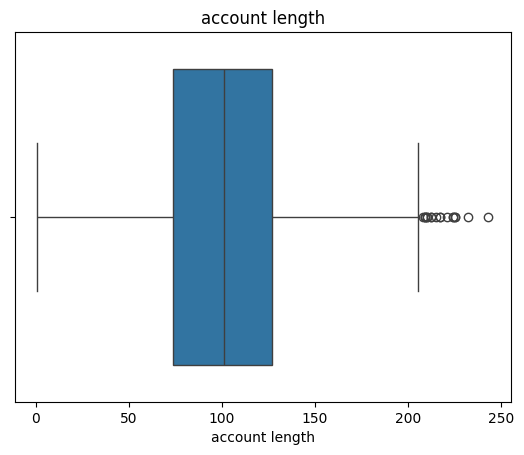

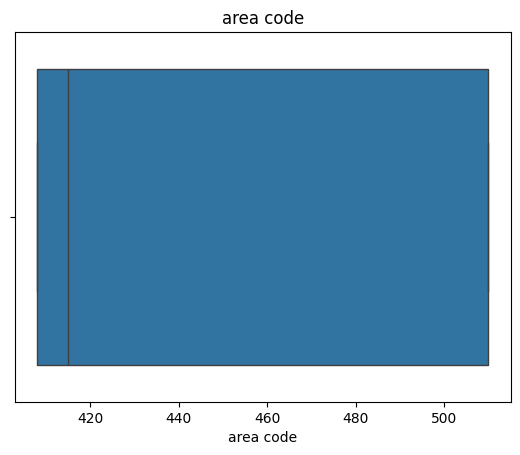

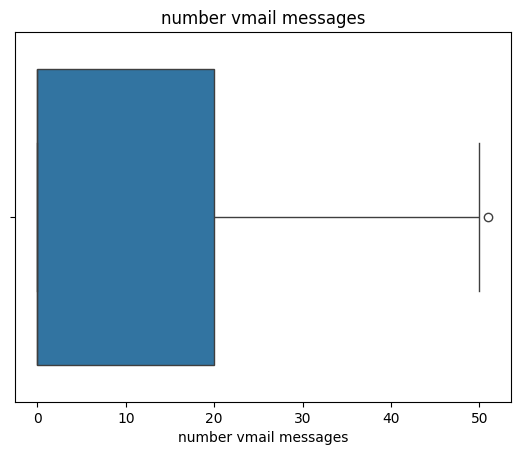

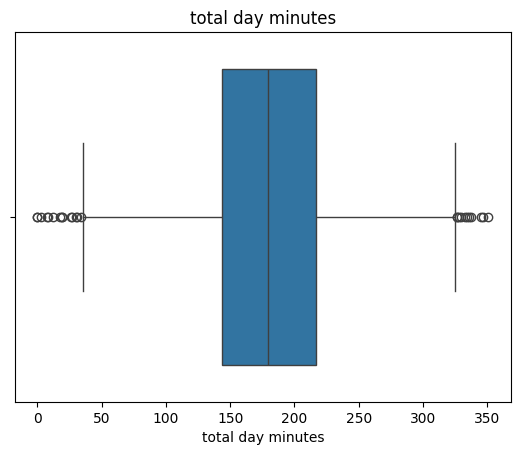

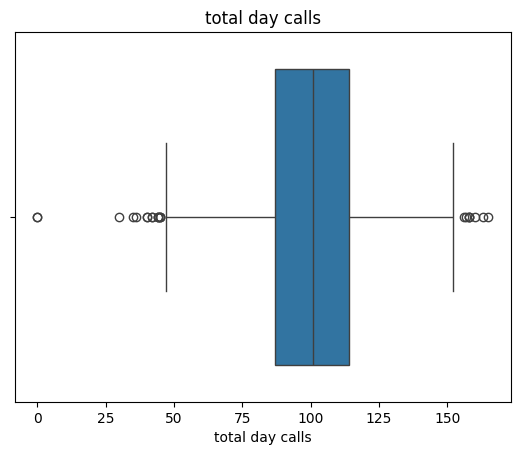

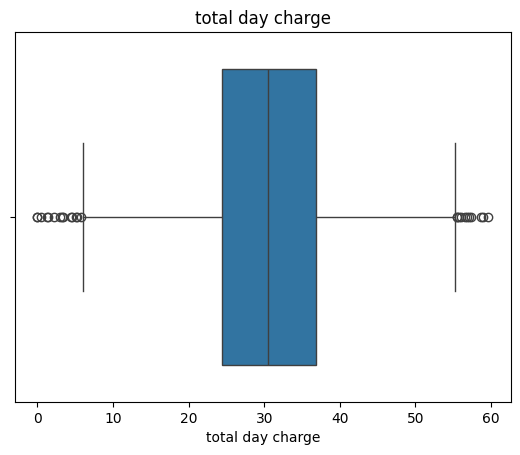

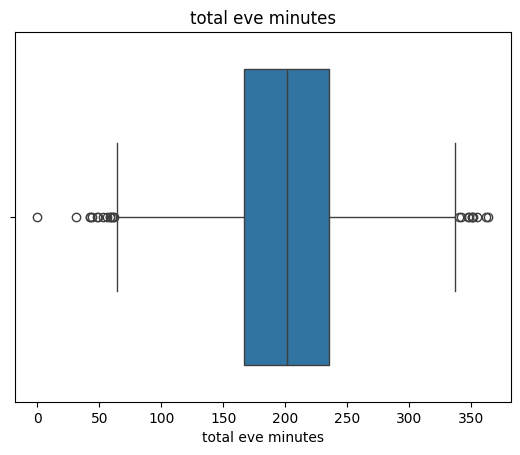

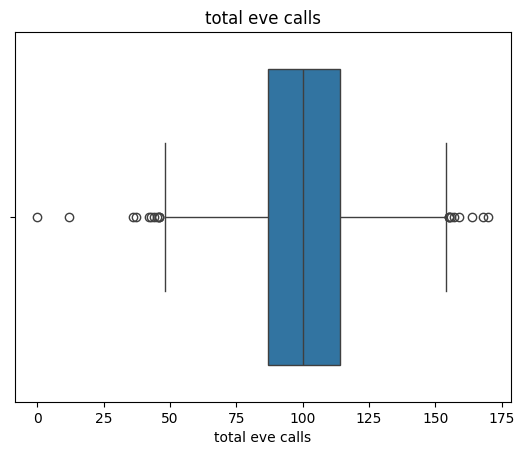

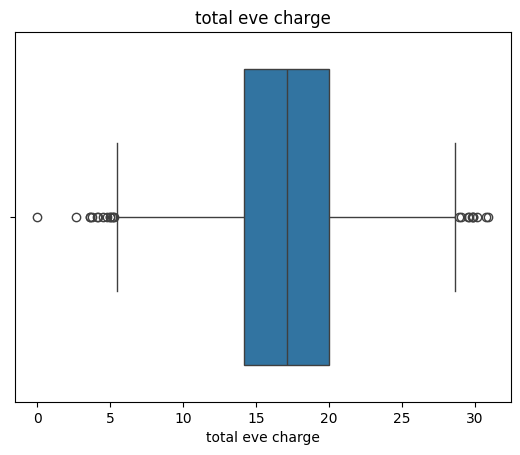

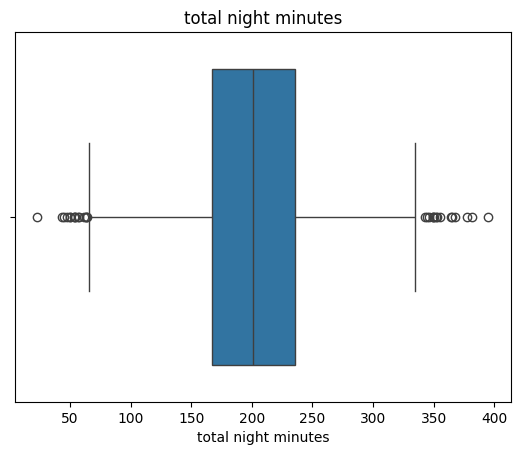

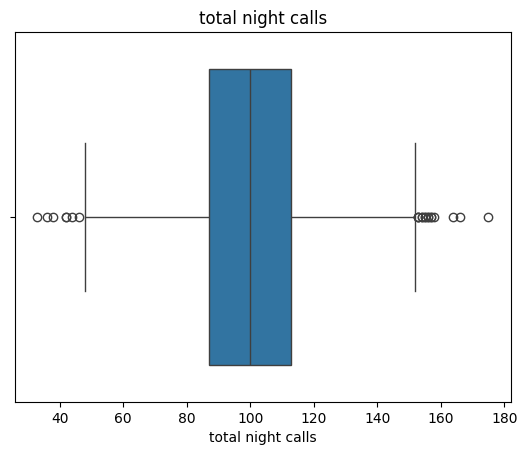

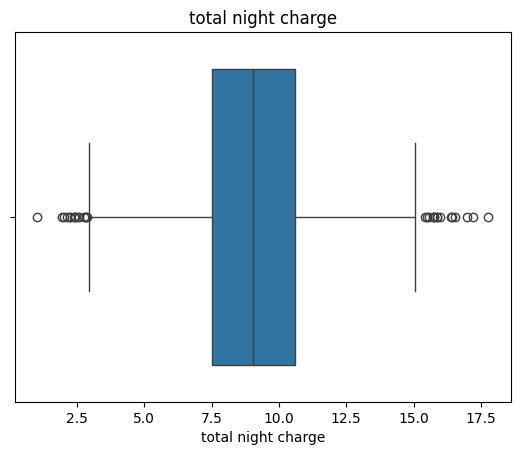

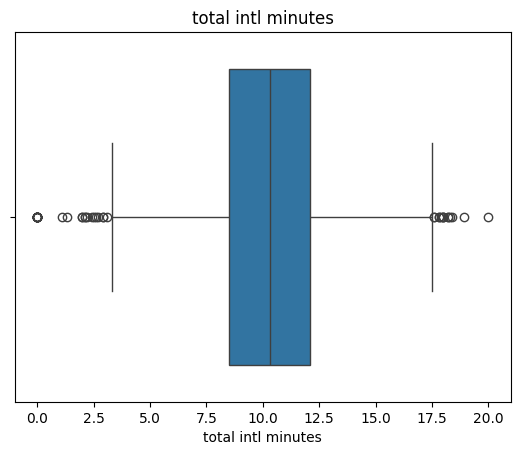

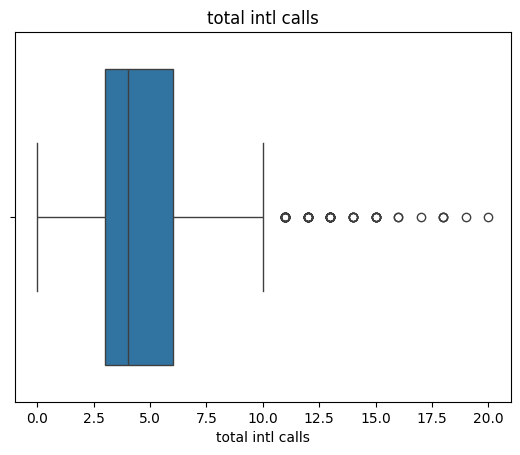

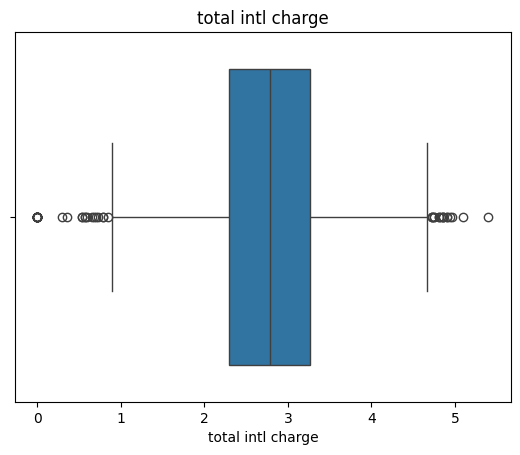

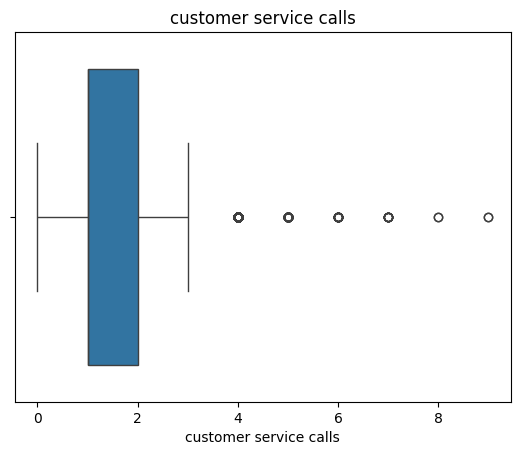

In [86]:
#Looking for outliers
for col in df.select_dtypes(include=np.number).columns:
    sns.boxplot(x=df[col]) 
    plt.title(col)
    plt.show() 

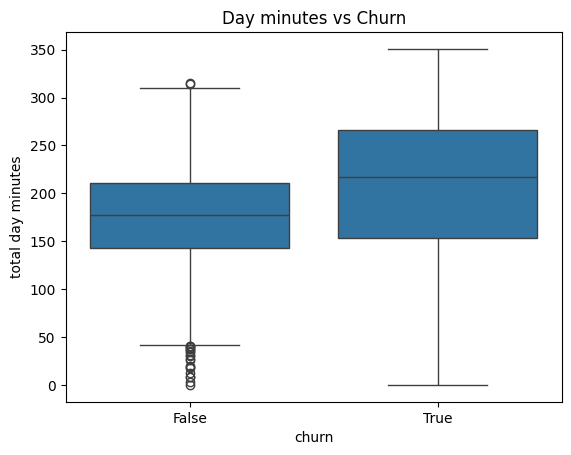

In [87]:
#Minutes versus churn
sns.boxplot(x='churn', y='total day minutes', data=df)
plt.title("Day minutes vs Churn")
plt.show()

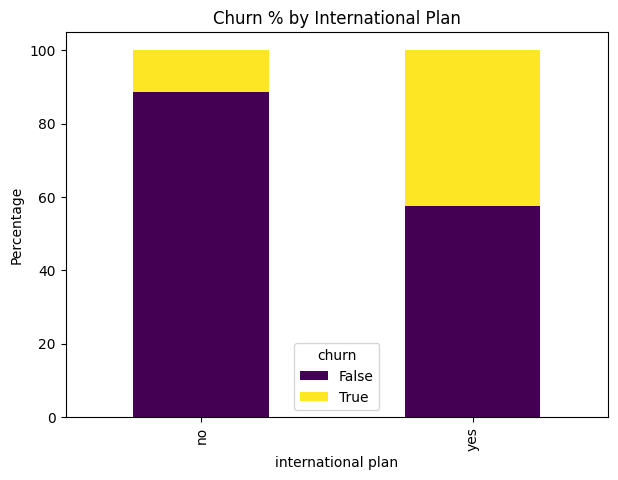

In [88]:
#International plan churn rate
ct=pd.crosstab(df['international plan'], df['churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(7,5), colormap='viridis')

plt.title('Churn % by International Plan')
plt.ylabel('Percentage')
plt.show()

## EDA Summary


1.The data has 3333 rows and 21 columns

2.There  were no mising values and duplicates

3.There is a great imbalance on the customer who will remain (2850) and those who will churn(483) therefore need for AUC and recall

4 Customer who called more for customer service churned

6.Strong correlations between charge and minutes creates multicollinearity one should be removed

5.Customer service has the highest correlation with churn, area code,account length night calls have near to zero corellation hence not able to predict churn while total international calls and number voice mail messages decreases churn

6.Customer who churn have higher number of minutes in a day

7 Customers who have no international plan have less churn rate while customers who have international plan have high churn rate



In [89]:
# Drop irrelevant and leakage-risk columns
# phone number is a unique ID has no predictive value
# area code  has low signal, redundant with state
# charge cols has r = 1.0 with their minute equivalents (confirmed in EDA)keeping both lets the model cheat data leakage

COLS_TO_DROP = ['phone number','area code','total day charge','total eve charge','total night charge','total intl charge',]
data = df.drop(columns=COLS_TO_DROP)

# Convert categorical variables
data['international plan'] = data['international plan'].map({'yes': 1, 'no': 0})
data['voice mail plan']    = data['voice mail plan'].map({'yes': 1, 'no': 0})
data['churn']              = data['churn'].astype(int)


# One-hot encode state (drop_first avoids multicollinearity)
data = pd.get_dummies(data, columns=['state'], drop_first=True)


In [90]:
# Features / target 
X = data.drop('churn', axis=1)
y = data['churn']

In [91]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [92]:
## Solving the imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights

array([0.58464912, 3.45336788])

In [93]:
# Checking data size + 20%split
print("Total dataset size:", len(X))

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("Expected test size (20%):", int(0.2 * len(X)))

Total dataset size: 3333
Train size: 2666
Test size: 667
Expected test size (20%): 666


In [94]:
# Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train)) #columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test)) #columns=X_test.columns)

## MODELING

In [95]:
#Model 1
#A DummyClassifier makes predictions using simple rules with no learning
#This exposes the accuracy trap
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy)*100}")
print(f"Recall   : {recall_score(y_test, y_pred_dummy, zero_division=0)*100}")
print(f"F1 Score : {f1_score(y_test, y_pred_dummy, zero_division=0)*100}")
print(f"Precision :{precision_score(y_test, y_pred_dummy, zero_division=0) * 100}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_dummy)*100}")




Accuracy : 85.45727136431785
Recall   : 0.0
F1 Score : 0.0
Precision :0.0
AUC Score: 50.0


In [96]:
#Model 2  Logistic Regression
#It assumes a linear decision boundary and requires scaled features
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100}")
print(f"Recall   : {recall_score(y_test, y_pred_lr, zero_division=0)*100}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr, zero_division=0)*100}")
print(f"Precision :{precision_score(y_test, y_pred_lr, zero_division=0) * 100}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_lr)*100}")




Accuracy : 74.5127436281859
Recall   : 70.10309278350515
F1 Score : 44.44444444444445
Precision :32.535885167464116
AUC Score: 72.68312533912099


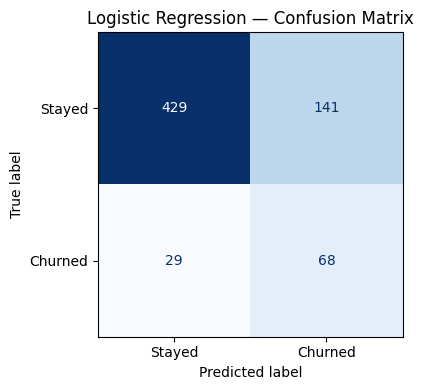

In [97]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),display_labels=['Stayed', 'Churned']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [98]:
## Model 3
#Decision tree
#They Capure non linear relationship
dt_base = DecisionTreeClassifier(random_state=42)
#Hyperparameter grid justification for each:
#   max_depth -controls overfitting; small = underfit, large = overfit
#   min_samples_split-min samples to split a node; higher = simpler tree
#   min_samples_leaf -min samples in a leaf; higher = smoother boundaries
#   class_weight- None vs balanced — tests whether upweighting churners helps
param_grid_dt = {
    'max_depth':        [3, 5, 7, 10],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight':     [None, 'balanced'],}
    
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring='recall',      # primary metric: catch as many churners as possible
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt)*100}")
print(f"Recall   : {recall_score(y_test, y_pred_dt, zero_division=0)*100}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt, zero_division=0)*100}")
print(f"Precision :{precision_score(y_test, y_pred_dt, zero_division=0) * 100}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_dt)*100}")




Accuracy : 90.25487256371814
Recall   : 72.16494845360825
F1 Score : 68.29268292682927
Precision :64.81481481481481
AUC Score: 82.7491408934708


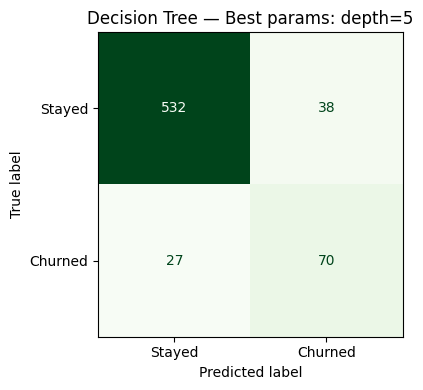

In [99]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=['Stayed', 'Churned']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f"Decision Tree — Best params: depth={grid_search_dt.best_params_['max_depth']}")
plt.tight_layout()
plt.show()

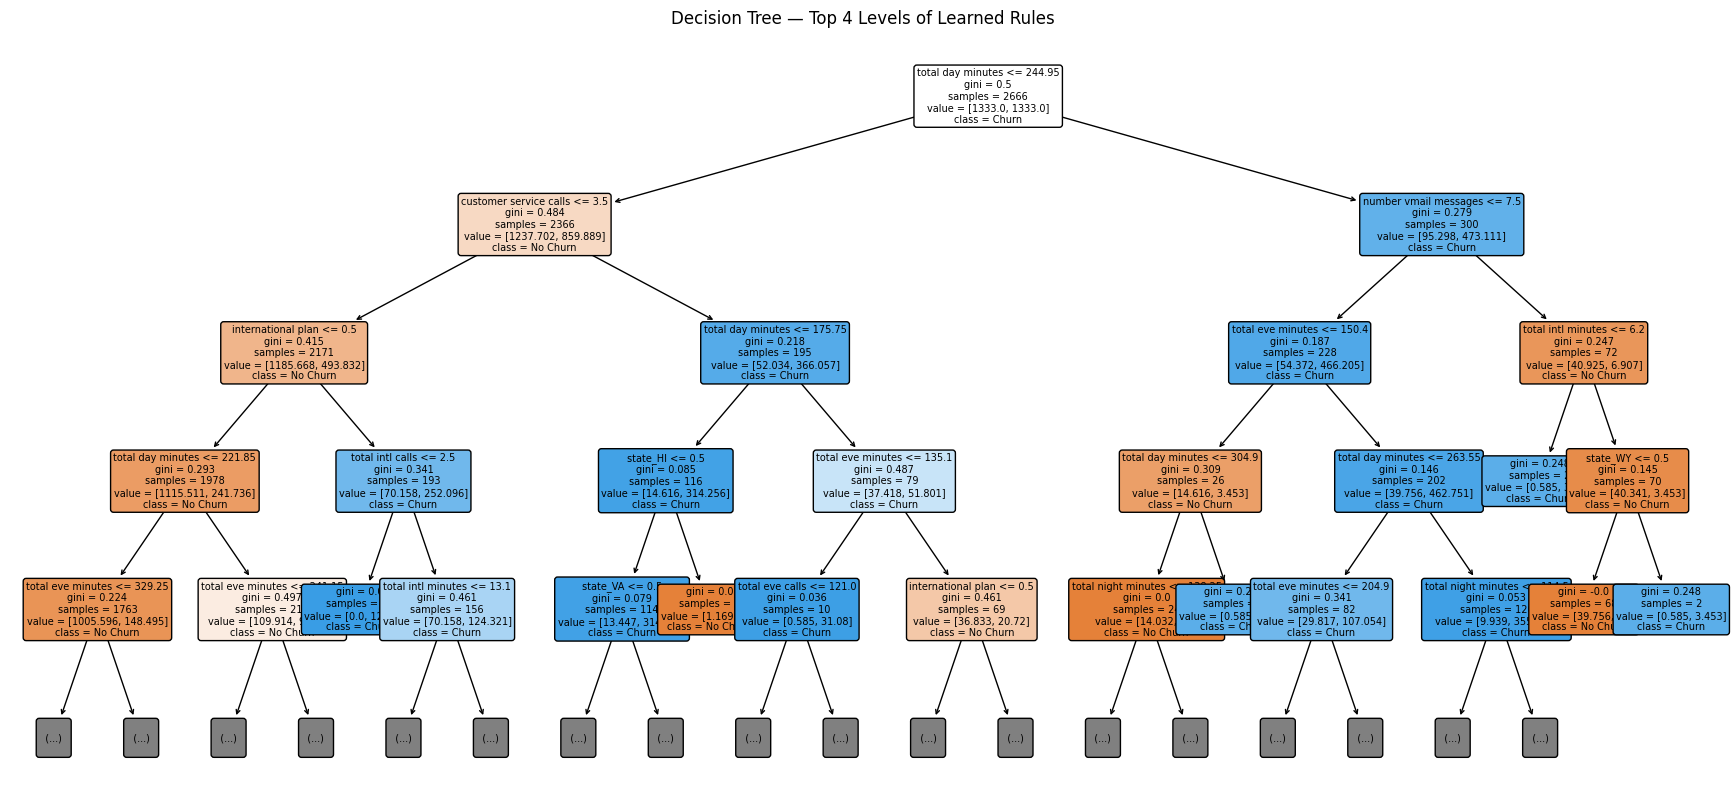

In [100]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True, fontsize=7,
    max_depth=4 ) # show top 4 levels for readability
plt.title("Decision Tree — Top 4 Levels of Learned Rules")
plt.show()

In [101]:
# BUILDIND EVALUATION TABLE
models = {"Dummy": y_pred_dummy,"Logistic Regression": y_pred_lr,"Decision Tree": y_pred_dt}
results = []

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3),
        "AUC SCORE":round(AUC,3),
        "Confusion Matrix": cm})

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC SCORE,Confusion Matrix
0,Dummy,0.855,0.000,0.000,0.000,0.500,"[[570, 0], [97, 0]]"
1,Logistic Regression,0.745,0.325,0.701,0.444,0.727,"[[429, 141], [29, 68]]"
2,Decision Tree,0.903,0.648,0.722,0.683,0.827,"[[532, 38], [27, 70]]"


# FINDINGS
 3 classifaction models were developed, Dummy,Logistic regression and Decison tree

 20% of data was used that is 667 customers, stratified to preserve the 14.5% churn rate

 Accuracy alone is misleading focus is on Recall, F1, Precision, AUC and Confusion Matrix.

### Dummy Model

Predicts everyone as not churn

97 customer are missed

Accuracy looks high (85.5%) but is misleading

Recall (0)it fails completely at detecting churn also on precision

AUR Score(50%) meaning its random guessing


### Logistic Regression

Catches 429 of churners but many false alarms 141, too many false negative resulting to higher operational cost through marketing and discounts
 
Accuracy of (74.5%) moderate performance

Recall(70.1%) good at finding churners

Precision (32.5%) many false alarms

F1 (44.4%) moderate balance

AUC (72.7%) decent separation ability

### Decision Tree

Detects 70 out of 97 churners

Fewer false positives compared to Logistic Regression

Accuracy (90.3% )strong overall performance

Precision (64.8%) much better quality of predictions

Recall (72.2%) strong churn detection

F1 (68.3%)best balance between precision and recall

AUC (82.7%)strong ability to separate churn vs non-churn



# RECOMMENDATION
### Use the Decision Tree as the primary model 
Reasons:
     
     Highest Accuracy (90.3%)
     
     Best AUC strongest class separation
     
     Best F1 Score balanced performance
    
    Good Recall catches most churners

Business impact

     Better identification of customers likely to leave
     
     More efficient retention targeting
     
     Balanced cost vs performance

### Use Logistic Regression as a secondary model

Reason 
      
      High Recall  detects most churners
      
      Lower precision many false positives

Use Logistic Regression for early warning or risk screening, not final decisions.

Business impact

     Helps ensure no potential churners are missed

     Can be used for proactive marketing campaigns
     
     Should be combined with  thresholds

### Do NOT use Dummy Classifier for decisions

Reason

Recall = 0, F1 = 0

It predicts everyone as non-churn

AUC random guessing

Only use Dummy model as a baseline benchmark, not for any business use.

### On Features

Features such as customer service,charges,minutes, voicemail,international plan have a strong effect on churn therefore the company can improve by

1.Increase customer quality through staff staining and service responsiveness

2.Compare charges with the industry charge so that customers don't switch to  your competitors

3.Intoduce flexible call  minutes packages as a form of discounts and marketing to customer inorder to retain them and attract new ones

4.Review international clients plans pricing and service efficiency ensuring fairness while maintaining operational sustainability 

# CONCLUSION

Overall,the Decision Tree model combined with these business insights provides a strong foundation for proactive churn management. 

By focusing on both predictive modeling and targeted business interventions, the company can significantly improve customer retention, reduce churn-related losses, and enhance long-term customer satisfaction.

